In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
seed = 1332
np.random.seed(seed)

# Dataset Preprocessing

In [3]:
df = pd.read_csv('data/adult.data', header=None)

df.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num', 
    'marital_status', 'occupation', 'relationship', 'race', 'sex', 
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Label Encoding

In [4]:
le = LabelEncoder()
encoders = {}

encoding_labels = [
    'workclass', 'education', 'marital_status', 'occupation', 
    'relationship', 'race', 'sex', 'native_country'
]

for attribute in encoding_labels:
    df[attribute] = le.fit_transform(df[attribute])
    encoders[attribute] = le

In [5]:
X, y = df.drop("income", axis=1), df["income"]
y = y.apply(lambda x: 1 if ">50K" in x else 0)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.8, random_state=seed)

In [7]:
X_train.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
18735,69,2,197288,11,9,2,4,0,4,1,0,0,35,39
30553,30,4,316471,9,13,4,1,1,4,1,0,0,50,39
22639,34,4,340917,14,15,2,4,0,4,1,2829,0,50,0
26693,34,4,242361,15,10,2,10,0,2,1,0,0,50,39
2605,31,4,209276,11,9,2,8,0,3,1,0,0,40,39


### Scaling Values

In [8]:
attributes_to_scale = list(
    set(X_train.columns).difference(set(X_train.columns).intersection(encoding_labels))
)

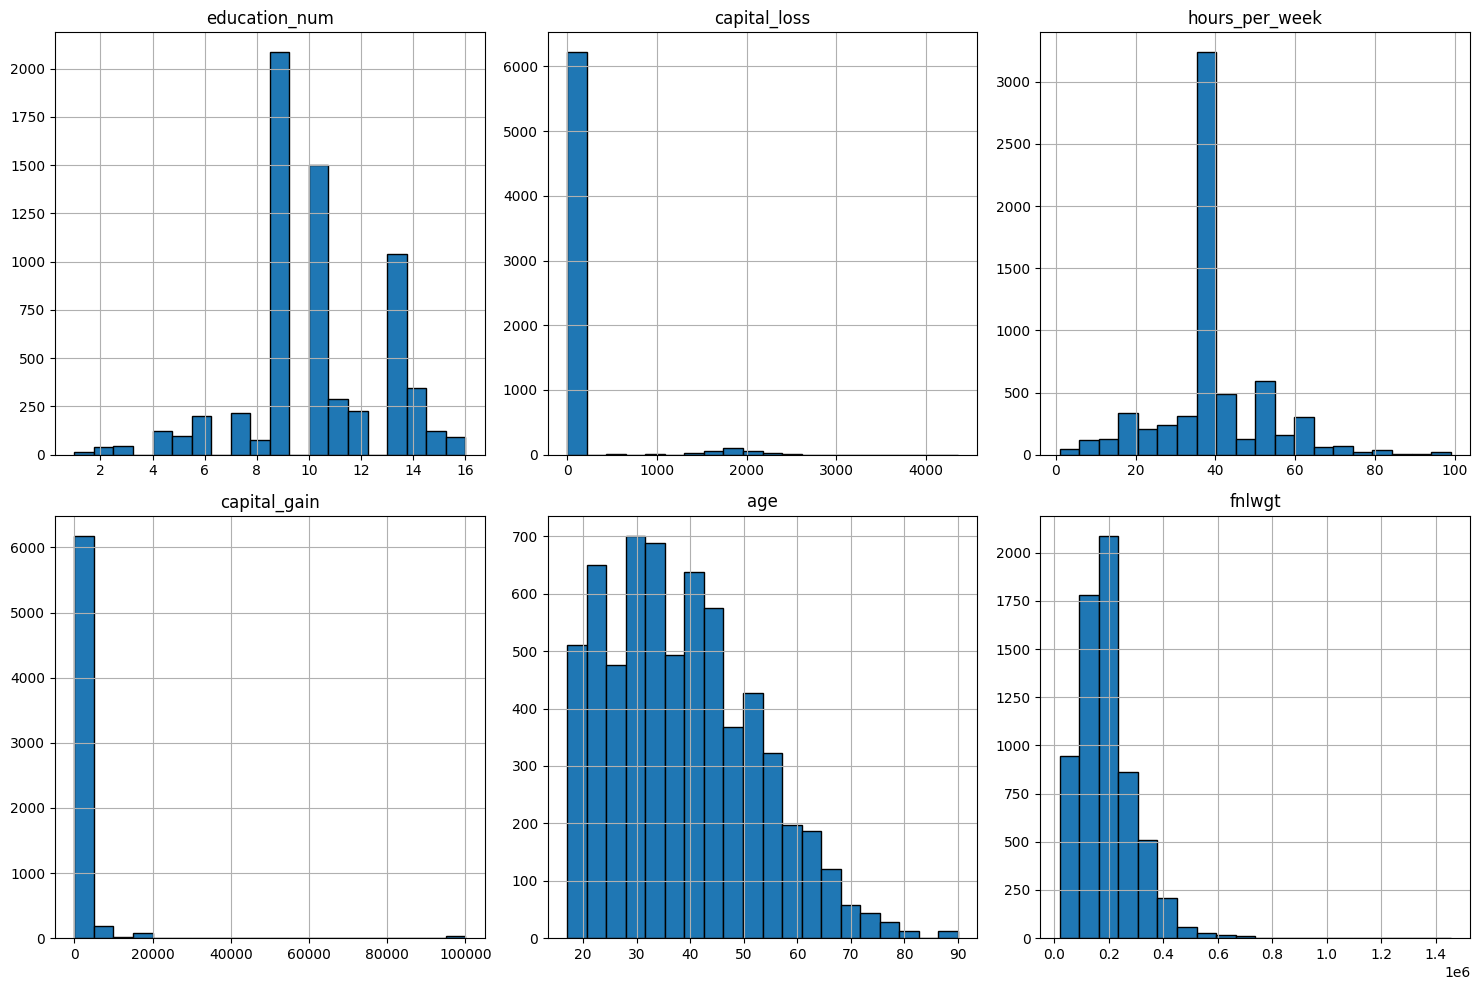

In [9]:
X_train[attributes_to_scale].hist(bins=20, figsize=(15, 10), layout=(-1, 3), edgecolor="black")
plt.tight_layout()
plt.show()

In [10]:
# scaler = StandardScaler()
# scalers = {}

# for attribute in attributes_to_scale:
#     X_train[attribute] = scaler.fit_transform(X_train[attribute].values.reshape(-1, 1))
#     scalers[attribute] = scaler

In [11]:
# X_train[attributes_to_scale].hist(bins=20, figsize=(15, 10), layout=(-1, 3), edgecolor="black")
# plt.tight_layout()
# plt.show()

In [12]:
# for attribute, scaler in scalers.items():
#     X_val[attribute] = scaler.transform(X_val[attribute].values.reshape(-1, 1))

In [13]:
# scalers

In [14]:
# X_val.head()

# TASK 1

In [15]:
class Metrics:

    def __init__(self):
        self.cls_counts = None
        self.num_samples = None

    def precompute(self, labels):
        self.num_samples = len(labels)
        self.cls_counts = {}

        for y in labels:
            if y not in self.cls_counts:
                self.cls_counts[y] = 1
            else:
                self.cls_counts[y] += 1

    def gini_index(self, labels):
        if len(labels) == 0:
            return 0.0
        self.precompute(labels)
        cls_squared = [
            (count / self.num_samples) ** 2 
            for count in self.cls_counts.values()
        ]

        return 1 - np.sum(cls_squared)

    def entropy(self, labels):
        if len(labels) == 0:
            return 0.0
        self.precompute(labels)

        prob = [
            (count / self.num_samples) * np.log2(count / self.num_samples)
            for count in self.cls_counts.values()
            if count > 0  # Prevents log(0) error
        ]

        return -np.sum(prob)

    def misclassification_error(self, labels):
        """Calculates 1 - max(P(class_i))"""
        if len(labels) == 0:
            return 0.0
        self.precompute(labels)
        
        max_prob = max(count / self.num_samples for count in self.cls_counts.values())
        return 1.0 - max_prob

    def split_information(self, child_splits, total_samples):
        """Calculates Intrinsic Information across child split branches."""
        if total_samples == 0:
            return 0.0
        split_info = 0.0
        for child_labels in child_splits:
            p = len(child_labels) / total_samples
            if p > 0:
                split_info -= p * np.log2(p)
        return split_info

    def gain_ratio(self, parent_labels, child_splits):
        parent_entropy = self.entropy(parent_labels)
        total_samples = len(parent_labels)

        if total_samples == 0:
            return 0.0

        weighted_child_entropy = sum(
            (len(child) / total_samples) * self.entropy(child)
            for child in child_splits
            if len(child) > 0
        )

        info_gain = parent_entropy - weighted_child_entropy
        split_info = self.split_information(child_splits, total_samples)

        if split_info == 0:
            return 0.0

        return info_gain / split_info

In [16]:
def split(train, test, metric="entropy", target_col=None):

    if hasattr(test, 'values'):
        y = test[target_col].values if target_col else test.values
    else:
        y = test

    metrics = Metrics()
    attribute_weighted_metric = {}
    attribute_split = {}

    for attribute in train.columns:

        if np.issubdtype(train[attribute].dtype, np.number):
            # Continuous attribute
            values = np.sort(np.unique(train[attribute]))
            thresholds = (values[:-1] + values[1:]) / 2

            splits = []
            for threshold in thresholds:
                left_idx = train[attribute] <= threshold
                right_idx = train[attribute] > threshold
                splits.append((left_idx, right_idx, threshold))

        else:
            # Categorical attribute
            classes = np.unique(train[attribute])

            splits = []
            for name in classes:
                left_idx = train[attribute] == name
                right_idx = train[attribute] != name
                splits.append((left_idx, right_idx, name))

        # Gain Ratio needs to be MAXIMIZED; impurity metrics need to be MINIMIZED
        best_metric = -float("inf") if metric == "gain_ratio" else float("inf")
        best_split = None

        for left_idx, right_idx, split_value in splits:

            left_samples = left_idx.sum()
            right_samples = right_idx.sum()

            # Skip invalid splits with empty sides
            if left_samples == 0 or right_samples == 0:
                continue

            if metric == "entropy":
                metric_left = metrics.entropy(y[left_idx])
                metric_right = metrics.entropy(y[right_idx])
                
                score = (
                    (left_samples / len(train)) * metric_left
                    + (right_samples / len(train)) * metric_right
                )

            elif metric == "gini":
                metric_left = metrics.gini_index(y[left_idx])
                metric_right = metrics.gini_index(y[right_idx])
                
                score = (
                    (left_samples / len(train)) * metric_left
                    + (right_samples / len(train)) * metric_right
                )

            elif metric == "misclassification_error":
                metric_left = metrics.misclassification_error(y[left_idx])
                metric_right = metrics.misclassification_error(y[right_idx])
                
                score = (
                    (left_samples / len(train)) * metric_left
                    + (right_samples / len(train)) * metric_right
                )

            elif metric == "gain_ratio":
                # Construct binary feature split representation for Split Info computation
                feature_binary_split = np.where(left_idx, 0, 1)
                
                score = metrics.gain_ratio(
                    parent_labels=y,
                    child_splits=[y[left_idx], y[right_idx]],
                    feature_values=feature_binary_split
                )

            else:
                raise ValueError(f"Unknown metric: {metric}")

            # Selection logic based on metric type
            if metric == "gain_ratio":
                if score > best_metric:
                    best_metric = score
                    best_split = split_value
            else:
                if score < best_metric:
                    best_metric = score
                    best_split = split_value

        attribute_weighted_metric[attribute] = best_metric
        attribute_split[attribute] = best_split

        print(f"{attribute}: best_{metric} = {best_metric:.4f}, split_value = {best_split}")

    return attribute_weighted_metric, attribute_split

In [17]:
split(X_train, y_train)

age: best_entropy = 0.7106, split_value = 30.5
workclass: best_entropy = 0.7794, split_value = 4.5
fnlwgt: best_entropy = 0.7854, split_value = 205673.5
education: best_entropy = 0.7585, split_value = 6.5
education_num: best_entropy = 0.7200, split_value = 12.5
marital_status: best_entropy = 0.6670, split_value = 2.5
occupation: best_entropy = 0.7722, split_value = 9.5
relationship: best_entropy = 0.6652, split_value = 0.5
race: best_entropy = 0.7823, split_value = 3.5
sex: best_entropy = 0.7530, split_value = 0.5
capital_gain: best_entropy = 0.6972, split_value = 7073.5
capital_loss: best_entropy = 0.7666, split_value = 1793.5
hours_per_week: best_entropy = 0.7457, split_value = 43.5
native_country: best_entropy = 0.7856, split_value = 35.5


({'age': 0.7105565161308455,
  'workclass': 0.779391893539193,
  'fnlwgt': 0.7853843451082572,
  'education': 0.7585420769750856,
  'education_num': 0.7199512439796802,
  'marital_status': 0.66696699561112,
  'occupation': 0.7721876797645659,
  'relationship': 0.6651671135722471,
  'race': 0.7822961589372771,
  'sex': 0.7529507538261686,
  'capital_gain': 0.697182336223876,
  'capital_loss': 0.76663152230354,
  'hours_per_week': 0.7456876231986329,
  'native_country': 0.7856113019877641},
 {'age': 30.5,
  'workclass': 4.5,
  'fnlwgt': 205673.5,
  'education': 6.5,
  'education_num': 12.5,
  'marital_status': 2.5,
  'occupation': 9.5,
  'relationship': 0.5,
  'race': 3.5,
  'sex': 0.5,
  'capital_gain': 7073.5,
  'capital_loss': 1793.5,
  'hours_per_week': 43.5,
  'native_country': 35.5})

In [18]:
class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        is_continuous=True,
        children=None,
        value=None,
        default_value=None
    ):
        self.feature = feature            
        self.threshold = threshold        
        self.is_continuous = is_continuous  
        self.children = children or {}    
        self.value = value                
        self.default_value = default_value 

    def is_leaf_node(self):
        return self.value is not None


class DecisionTreeClassifier:

    def __init__(
        self,
        criterion="entropy",
        max_depth=10,
        min_samples_split=2
    ):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.metrics = Metrics()

    def _impute_missing(self, column):
        if np.issubdtype(column.dtype, np.number):
            return column.median()
        else:
            mode_vals = column.mode()
            return mode_vals[0] if not mode_vals.empty else column.dropna().iloc[0]

    def _calculate_score(self, parent_y, child_splits):
        total_samples = len(parent_y)
        
        if self.criterion == "entropy":
            # Information Gain
            parent_imp = self.metrics.entropy(parent_y)
            child_imp = sum((len(c) / total_samples) * self.metrics.entropy(c) for c in child_splits)
            return parent_imp - child_imp

        elif self.criterion == "gini":
            # Gini Reduction
            parent_imp = self.metrics.gini_index(parent_y)
            child_imp = sum((len(c) / total_samples) * self.metrics.gini_index(c) for c in child_splits)
            return parent_imp - child_imp

        elif self.criterion == "misclassification_error":
            # Error Reduction
            parent_imp = self.metrics.misclassification_error(parent_y)
            child_imp = sum((len(c) / total_samples) * self.metrics.misclassification_error(c) for c in child_splits)
            return parent_imp - child_imp

        elif self.criterion == "gain_ratio":
            return self.metrics.gain_ratio(parent_y, child_splits)

        else:
            raise ValueError(f"Unknown criterion: {self.criterion}")

    def _find_best_split(self, X, y):
        best_score = -float("inf")
        best_feature = None
        best_threshold = None
        best_is_continuous = True
        best_splits = None

        for attribute in sorted(X.columns):
            col = X[attribute].copy()
            
            if col.isnull().any():
                col = col.fillna(self._impute_missing(col))

            is_num = np.issubdtype(col.dtype, np.number)

            if is_num:
                valid_vals = col.dropna()
                values = np.sort(np.unique(valid_vals))
                thresholds = (values[:-1] + values[1:]) / 2

                for t in thresholds:
                    left_mask = col <= t
                    right_mask = col > t

                    if left_mask.sum() == 0 or right_mask.sum() == 0:
                        continue

                    child_splits = [y[left_mask], y[right_mask]]
                    score = self._calculate_score(y, child_splits)

                    if score > best_score:
                        best_score = score
                        best_feature = attribute
                        best_threshold = t
                        best_is_continuous = True
                        best_splits = {"<=": left_mask, ">": right_mask}

            else:
                categories = np.unique(col.dropna())
                if len(categories) <= 1:
                    continue

                split_masks = {c: (col == c) for c in categories}
                child_splits = [y[mask] for mask in split_masks.values()]

                score = self._calculate_score(y, child_splits)

                if score > best_score:
                    best_score = score
                    best_feature = attribute
                    best_threshold = None
                    best_is_continuous = False
                    best_splits = split_masks

        return best_feature, best_threshold, best_is_continuous, best_splits

    def _most_common_label(self, y):
        if len(y) == 0:
            return None
        values, counts = np.unique(y, return_counts=True)
        max_count = np.max(counts)
        candidates = values[counts == max_count]
        return sorted(candidates)[0]

    def _build_tree(self, X, y, depth=0):
        num_samples = len(y)
        unique_labels = np.unique(y)

        if depth >= self.max_depth or len(unique_labels) <= 1 or num_samples < self.min_samples_split:
            return Node(value=self._most_common_label(y))

        feat, threshold, is_cont, splits = self._find_best_split(X, y)

        if feat is None or splits is None:
            return Node(value=self._most_common_label(y))

        default_val = self._most_common_label(y)
        children = {}

        for key, mask in splits.items():
            if mask.sum() == 0:
                children[key] = Node(value=default_val)
            else:
                children[key] = self._build_tree(X[mask], y[mask], depth + 1)

        return Node(
            feature=feat,
            threshold=threshold,
            is_continuous=is_cont,
            children=children,
            default_value=default_val
        )

    def fit(self, X, y):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        y_arr = np.array(y)
        self.root = self._build_tree(X_df, y_arr)

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        val = x[node.feature]

        if pd.isnull(val):
            return node.default_value

        if node.is_continuous:
            branch = "<=" if val <= node.threshold else ">"
            if branch in node.children:
                return self._traverse_tree(x, node.children[branch])
        else:
            if val in node.children:
                return self._traverse_tree(x, node.children[val])

        return node.default_value

    def predict(self, X):
        X_df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)
        return np.array([self._traverse_tree(row, self.root) for _, row in X_df.iterrows()])

    def print_tree(self, figsize=(20, 10)):
        """
        Plots the decision tree diagrammatically without node overlapping
        by placing leaf nodes at equal horizontal intervals.
        """
        if self.root is None:
            print("Tree has not been fitted yet!")
            return

        # 1. Helper to count leaf nodes (determines required width)
        def _count_leaves(node):
            if node is None or node.is_leaf_node() or not node.children:
                return 1
            return sum(_count_leaves(child) for child in node.children.values())

        # 2. Helper to get maximum depth (determines required height)
        def _get_max_depth(node):
            if node is None or node.is_leaf_node() or not node.children:
                return 1
            return 1 + max(_get_max_depth(child) for child in node.children.values())

        total_leaves = _count_leaves(self.root)
        total_depth = _get_max_depth(self.root)

        fig, ax = plt.subplots(figsize=figsize)
        ax.axis("off")

        leaf_counter = 0  # Tracks leaf position from left to right [0, total_leaves - 1]

        def _plot_node(node, depth=1):
            nonlocal leaf_counter

            if node is None:
                return 0.0, 0.0

            # Vertical coordinate proportional to depth
            y = 1.0 - (depth / (total_depth + 1))

            # --- LEAF NODE ---
            if node.is_leaf_node() or not node.children:
                # Place leaf horizontally based on global leaf count
                x = (leaf_counter + 0.5) / total_leaves
                leaf_counter += 1

                label = f"Class: {node.value}"
                bbox_props = dict(boxstyle="round,pad=0.3", fc="#a1d99b", ec="green", lw=1.5)
                ax.text(x, y, label, ha="center", va="center", bbox=bbox_props, fontsize=8, fontweight="bold")
                return x, y

            # --- INTERNAL DECISION NODE ---
            child_coords = []
            for branch_key, child_node in node.children.items():
                cx, cy = _plot_node(child_node, depth + 1)
                child_coords.append((branch_key, child_node, cx, cy))

            # Parent x-coordinate is centered exactly over its children
            x = sum(cx for _, _, cx, _ in child_coords) / len(child_coords)

            # Node label formatting
            if node.is_continuous:
                label = f"{node.feature}\n<= {node.threshold:.2f}"
            else:
                label = f"{node.feature}"

            bbox_props = dict(boxstyle="square,pad=0.4", fc="#9ecae1", ec="#3182bd", lw=1.5)
            ax.text(x, y, label, ha="center", va="center", bbox=bbox_props, fontsize=8, fontweight="bold")

            # Draw edges to children
            for branch_key, child_node, cx, cy in child_coords:
                ax.plot([x, cx], [y - 0.02, cy + 0.02], color="black", lw=1.0, zorder=1)

                # Edge text label formatting
                if node.is_continuous:
                    edge_label = "T" if branch_key == "<=" else "F"
                    edge_color = "darkgreen" if branch_key == "<=" else "darkred"
                else:
                    # Truncate long category names to keep image readable
                    edge_label = str(branch_key)
                    if len(edge_label) > 8:
                        edge_label = edge_label[:6] + ".."
                    edge_color = "darkblue"

                # Draw branch label on the edge line
                x_mid = (x + cx) / 2
                y_mid = (y + cy) / 2
                ax.text(
                    x_mid,
                    y_mid,
                    edge_label,
                    color=edge_color,
                    fontsize=7,
                    fontweight="bold",
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
                    zorder=2
                )

            return x, y

        # Start recursive plotting from root
        _plot_node(self.root, depth=1)
        
        plt.title("Decision Tree Visualization", fontsize=14, fontweight="bold", pad=20)
        plt.tight_layout()
        plt.show()

In [19]:
tree = DecisionTreeClassifier(criterion="gini", max_depth=5)
tree.fit(X_train, y_train)

Learned Tree Structure:


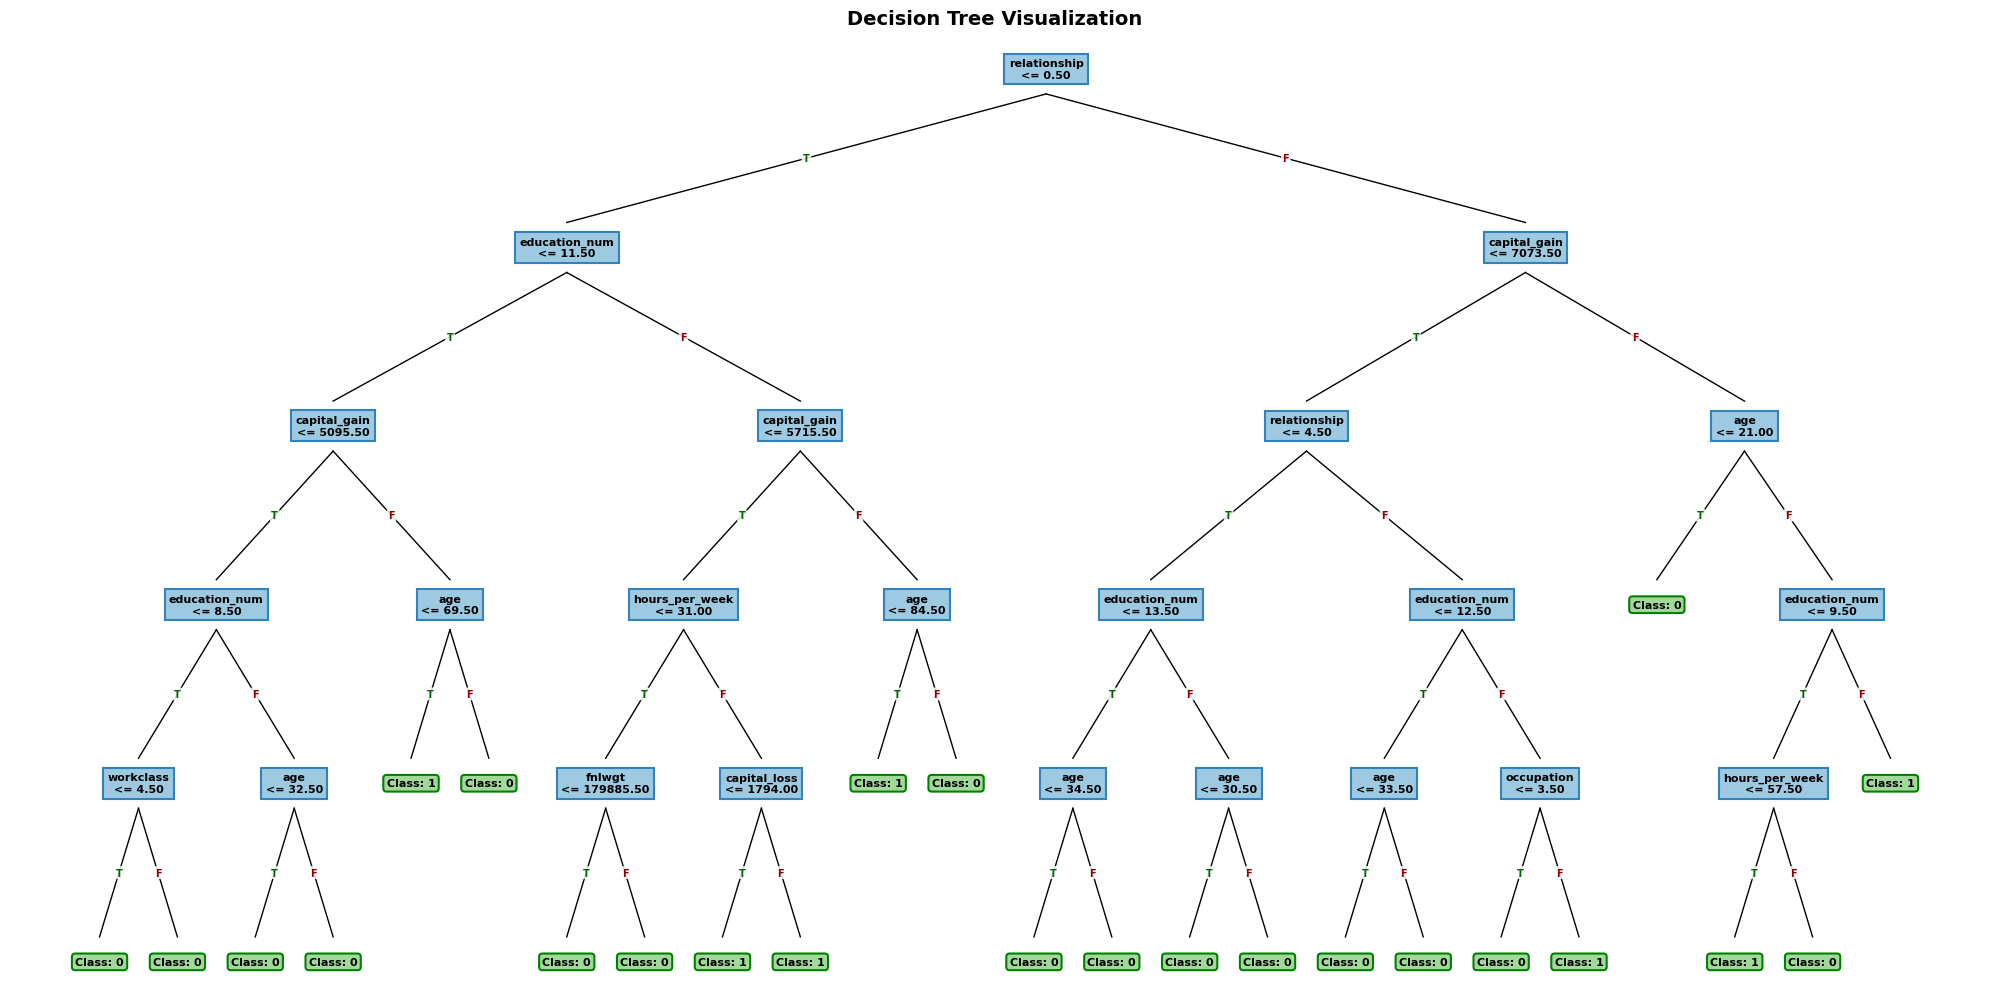

In [20]:
# Print decision paths
print("Learned Tree Structure:")
tree.print_tree(figsize=(20, 10))

In [21]:
# Predict on new data
preds = tree.predict(X_val)
print("\nPredictions:", preds)


Predictions: [0 0 1 ... 0 0 0]


In [22]:
from sklearn.metrics import accuracy_score
accuracy_score(np.array(preds), y_val.values)

0.8442550577757304

In [36]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(
    criterion = "gini",
    max_depth = 5
)

In [37]:
clf.fit(X_train, y_train)

ValueError: could not convert string to float: ' Local-gov'

In [ ]:
y_pred = clf.predict(X_val)

In [ ]:
accuracy_score()

# TASK 2:

In [23]:
import numpy as np
import pandas as pd

# =====================================================================
# TASK 2: SPLIT SELECTION INVESTIGATOR
# =====================================================================

def evaluate_root_splits(X, y):
    """
    Evaluates all potential splits across all features at the root node
    using Gini Index, Information Gain, Gain Ratio, and Misclassification Error.
    """
    metrics = Metrics()
    results = []

    parent_entropy = metrics.entropy(y)
    parent_gini = metrics.gini_index(y)
    parent_error = metrics.misclassification_error(y)
    total_samples = len(y)

    for attribute in sorted(X.columns):
        col = X[attribute].copy()
        
        # Handle missing values via temporary median/mode imputation
        if col.isnull().any():
            if np.issubdtype(col.dtype, np.number):
                col = col.fillna(col.median())
            else:
                col = col.fillna(col.mode()[0])

        is_num = np.issubdtype(col.dtype, np.number)

        if is_num:
            # Candidate continuous threshold splits
            valid_vals = col.dropna()
            values = np.sort(np.unique(valid_vals))
            thresholds = (values[:-1] + values[1:]) / 2

            for t in thresholds:
                left_mask = col <= t
                right_mask = col > t

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                child_splits = [y[left_mask], y[right_mask]]
                
                # Metric Calculations
                w_entropy = sum((len(c)/total_samples) * metrics.entropy(c) for c in child_splits)
                w_gini = sum((len(c)/total_samples) * metrics.gini_index(c) for c in child_splits)
                w_error = sum((len(c)/total_samples) * metrics.misclassification_error(c) for c in child_splits)
                
                ig = parent_entropy - w_entropy
                gini_red = parent_gini - w_gini
                error_red = parent_error - w_error
                gr = metrics.gain_ratio(y, child_splits)

                results.append({
                    'feature': attribute,
                    'split_type': 'continuous',
                    'split_detail': f'<= {t:.4f}',
                    'threshold': t,
                    'info_gain': ig,
                    'gini_reduction': gini_red,
                    'gain_ratio': gr,
                    'error_reduction': error_red
                })
        else:
            # Multiway split for categorical features
            categories = np.unique(col.dropna())
            if len(categories) <= 1:
                continue

            child_splits = [y[col == c] for c in categories]
            
            w_entropy = sum((len(c)/total_samples) * metrics.entropy(c) for c in child_splits)
            w_gini = sum((len(c)/total_samples) * metrics.gini_index(c) for c in child_splits)
            w_error = sum((len(c)/total_samples) * metrics.misclassification_error(c) for c in child_splits)

            ig = parent_entropy - w_entropy
            gini_red = parent_gini - w_gini
            error_red = parent_error - w_error
            gr = metrics.gain_ratio(y, child_splits)

            results.append({
                'feature': attribute,
                'split_type': 'categorical_multiway',
                'split_detail': f'Multiway ({len(categories)} categories)',
                'threshold': None,
                'info_gain': ig,
                'gini_reduction': gini_red,
                'gain_ratio': gr,
                'error_reduction': error_red
            })

    res_df = pd.DataFrame(results)

    # -------------------------------------------------------------
    # REPORT BEST SPLITS AT ROOT NODE
    # -------------------------------------------------------------
    print("==================================================")
    print("1. BEST SPLIT AT ROOT NODE BY CRITERION")
    print("==================================================")
    
    criteria_map = {
        'Gini Index Reduction': 'gini_reduction',
        'Information Gain': 'info_gain',
        'Gain Ratio': 'gain_ratio',
        'Misclassification Error Reduction': 'error_reduction'
    }

    for crit_name, col_name in criteria_map.items():
        best_row = res_df.sort_values(by=[col_name, 'feature'], ascending=[False, True]).iloc[0]
        print(f"• {crit_name}: Feature '{best_row['feature']}' ({best_row['split_detail']}) | Score: {best_row[col_name]:.4f}")

    return res_df


def compare_multiway_vs_binary(X, y, cat_feature):
    """
    Compares multiway splitting against all valid binary partitions 
    for a chosen categorical feature (Requirement 3).
    """
    metrics = Metrics()
    col = X[cat_feature].copy().dropna()
    categories = np.unique(col)
    
    print("\n==================================================")
    print(f"3. MULTIWAY VS BINARY PARTITIONS FOR '{cat_feature}'")
    print("==================================================")

    # 1. Multiway
    child_multi = [y[col == c] for c in categories]
    ig_multi = metrics.entropy(y) - sum((len(c)/len(y)) * metrics.entropy(c) for c in child_multi)
    gr_multi = metrics.gain_ratio(y, child_multi)
    
    print(f"Multiway Split ({len(categories)} branches):")
    print(f"  Info Gain: {ig_multi:.4f} | Gain Ratio: {gr_multi:.4f}\n")

    # 2. Binary Partitions (Subset vs Rest)
    print("Binary Partition Candidates:")
    from itertools import combinations
    
    # Generate unique binary partitions of subsets
    n = len(categories)
    for r in range(1, (n // 2) + 1):
        for subset in combinations(categories, r):
            group1_mask = col.isin(subset)
            group2_mask = ~group1_mask
            
            child_binary = [y[group1_mask], y[group2_mask]]
            ig_bin = metrics.entropy(y) - sum((len(c)/len(y)) * metrics.entropy(c) for c in child_binary)
            gr_bin = metrics.gain_ratio(y, child_binary)

            set1_str = "{" + ", ".join(map(str, subset)) + "}"
            print(f"  Split {set1_str} vs Rest -> Info Gain: {ig_bin:.4f} | Gain Ratio: {gr_bin:.4f}")


def print_manual_calculation_example(parent_labels, child_splits, feature_name, split_label):
    """
    Prints step-by-step complete manual calculations for a split (Requirement 4).
    """
    metrics = Metrics()
    N = len(parent_labels)

    print("\n==================================================")
    print(f"4. MANUAL CALCULATION FOR SPLIT: {feature_name} ({split_label})")
    print("==================================================")

    # Parent calculations
    p_entropy = metrics.entropy(parent_labels)
    p_gini = metrics.gini_index(parent_labels)
    p_error = metrics.misclassification_error(parent_labels)

    print(f"Parent Node (N = {N}):")
    print(f"  Labels count: {dict(pd.Series(parent_labels).value_counts())}")
    print(f"  Parent Entropy = {p_entropy:.4f}")
    print(f"  Parent Gini = {p_gini:.4f}")
    print(f"  Parent Misclassification Error = {p_error:.4f}\n")

    # Children calculations
    w_entropy, w_gini, w_error = 0.0, 0.0, 0.0
    split_info = 0.0

    print("Child Nodes:")
    for idx, child in enumerate(child_splits):
        n_c = len(child)
        weight = n_c / N
        c_ent = metrics.entropy(child)
        c_gini = metrics.gini_index(child)
        c_err = metrics.misclassification_error(child)

        w_entropy += weight * c_ent
        w_gini += weight * c_gini
        w_error += weight * c_err
        if weight > 0:
            split_info -= weight * np.log2(weight)

        print(f"  Child {idx + 1} (n = {n_c}, weight = {weight:.4f}):")
        print(f"    Counts: {dict(pd.Series(child).value_counts())}")
        print(f"    Entropy: {c_ent:.4f} | Gini: {c_gini:.4f} | Error: {c_err:.4f}")

    print("\nFinal Split Metrics:")
    print(f"  1. Information Gain = {p_entropy:.4f} - {w_entropy:.4f} = {p_entropy - w_entropy:.4f}")
    print(f"  2. Split Information = {split_info:.4f}")
    print(f"  3. Gain Ratio = {(p_entropy - w_entropy) / split_info:.4f}" if split_info > 0 else "  3. Gain Ratio = 0.0")
    print(f"  4. Gini Reduction = {p_gini:.4f} - {w_gini:.4f} = {p_gini - w_gini:.4f}")
    print(f"  5. Misclassification Error Reduction = {p_error:.4f} - {w_error:.4f} = {p_error - w_error:.4f}")

In [25]:
temp_df_X.head()

,age,education_num,sex,capital_gain,capital_loss
0,39,13,Male,2174,0
1,50,13,Male,0,0
2,38,9,Male,0,0
3,53,7,Male,0,0
4,28,13,Female,0,0


In [26]:
res_df = evaluate_root_splits(temp_df_X, temp_df_y)

compare_multiway_vs_binary(temp_df_X, temp_df_y, cat_feature="sex") 

sample_split = [temp_df_y[temp_df_X["age"] <= 30], temp_df_y[temp_df_X["age"] > 30]]
print_manual_calculation_example(temp_df_y.values, sample_split, "age", "<= 30")

1. BEST SPLIT AT ROOT NODE BY CRITERION
• Gini Index Reduction: Feature 'capital_gain' (<= 5119.0000) | Score: 0.0509
• Information Gain: Feature 'capital_gain' (<= 7073.5000) | Score: 0.0870
• Gain Ratio: Feature 'capital_gain' (<= 7073.5000) | Score: 0.3400
• Misclassification Error Reduction: Feature 'capital_gain' (<= 5119.0000) | Score: 0.0434

3. MULTIWAY VS BINARY PARTITIONS FOR 'sex'
Multiway Split (2 branches):
  Info Gain: 0.0372 | Gain Ratio: 0.0406

Binary Partition Candidates:
  Split { Female} vs Rest -> Info Gain: 0.0372 | Gain Ratio: 0.0406
  Split { Male} vs Rest -> Info Gain: 0.0372 | Gain Ratio: 0.0406

4. MANUAL CALCULATION FOR SPLIT: age (<= 30)
Parent Node (N = 32561):
  Labels count: {0: 24720, 1: 7841}
  Parent Entropy = 0.7964
  Parent Gini = 0.3656
  Parent Misclassification Error = 0.2408

Child Nodes:
  Child 1 (n = 10572, weight = 0.3247):
    Counts: {0: 9890, 1: 682}
    Entropy: 0.3451 | Gini: 0.1207 | Error: 0.0645
  Child 2 (n = 21989, weight = 0.6753)

In [27]:
import numpy as np
import pandas as pd

def run_task_3_experiment(X_train, y_train, X_val, y_val):
    """
    Appends UniqueID to dataset and compares Information Gain vs Gain Ratio performance.
    """
    # 1. Add artificial UniqueID feature
    X_train_trap = X_train.copy()
    X_val_trap = X_val.copy()

    X_train_trap['UniqueID'] = [f"ID_{i}" for i in range(len(X_train_trap))]
    X_val_trap['UniqueID'] = [f"ID_{i}" for i in range(len(X_train_trap), len(X_train_trap) + len(X_val_trap))]

    print("==================================================")
    print("TASK 3: INFORMATION GAIN TRAP EXPERIMENT")
    print("==================================================")

    for criterion in ["entropy", "gain_ratio"]:
        tree = DecisionTreeClassifier(criterion=criterion, max_depth=10)
        tree.fit(X_train_trap, y_train)

        train_acc = (tree.predict(X_train_trap) == y_train).mean() * 100
        val_acc = (tree.predict(X_val_trap) == y_val).mean() * 100

        print(f"\nCriterion: {criterion.upper()}")
        print(f"Root Split Feature: {tree.root.feature}")
        print(f"Training Accuracy:   {train_acc:.2f}%")
        print(f"Validation Accuracy: {val_acc:.2f}%")


In [ ]:
run_task_3_experiment(X_train, y_train, X_val, y_val)

In [ ]:
import numpy as np

def compute_node_impurity(y, metric="gini"):
    if len(y) == 0:
        return 0.0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)

    if metric == "gini":
        return 1.0 - np.sum(probs ** 2)
    elif metric == "entropy":
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))
    elif metric == "error":
        return 1.0 - np.max(probs)
    else:
        raise ValueError(f"Unsupported metric: {metric}")

def find_best_feature_split(X, y, metric="gini"):
    X = np.asarray(X)
    y = np.asarray(y)

    n_samples, n_features = X.shape
    parent_impurity = compute_node_impurity(y, metric=metric)

    best_split = {
        "feature_idx": None,
        "threshold": None,
        "weighted_impurity": float("inf"),
        "impurity_gain": 0.0
    }

    for feature_idx in range(n_features):
        feature_values = X[:, feature_idx]
        thresholds = np.unique(feature_values)

        for t in thresholds:
            left_mask = feature_values <= t
            right_mask = ~left_mask

            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue

            y_left = y[left_mask]
            y_right = y[right_mask]

            w_left = len(y_left) / n_samples
            w_right = len(y_right) / n_samples
            weighted_imp = (w_left * compute_node_impurity(y_left, metric=metric) +
                            w_right * compute_node_impurity(y_right, metric=metric))

            if weighted_imp < best_split["weighted_impurity"]:
                best_split["feature_idx"] = feature_idx
                best_split["threshold"] = t
                best_split["weighted_impurity"] = weighted_imp
                best_split["impurity_gain"] = parent_impurity - weighted_imp

    return best_split

In [ ]:
find_best_feature_split(temp_df_X.values, temp_df_y.values)

{'feature_idx': 2,
 'threshold': 5060,
 'weighted_impurity': 0.31469230767240586,
 'impurity_gain': 0.050948321304942756}

In [ ]:
gini(temp_df_X.values, temp_df_y.values)

{0: 24720, 1: 7841}


In [ ]:
temp_df_X.values

array([[   39,    13,  2174,     0],
       [   50,    13,     0,     0],
       [   38,     9,     0,     0],
       ...,
       [   58,     9,     0,     0],
       [   22,     9,     0,     0],
       [   52,     9, 15024,     0]], dtype=int64)

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.left = left
        self.right = right
        self.threshold = threshold
        self.value = None
    
    def is_leaf_node(self):
        return self.value is not None

class DecisionTree:
    def __init__(self,):
        self.root = None
        
    